# XGBoost Feature Importance with SHAP
Loads the saved model from `artifacts/model_pipeline_random.pkl` (60/20/20 split).
Data is reloaded only to reconstruct `X_train` / `X_test` with the same seed — no retraining.

In [8]:
import sys, os
sys.path.append(os.path.join('..'))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.data_loader import RealExcelDataLoader
from src.config import TARGET_COL, FEATURE_DESCRIPTIONS, set_seed

set_seed(42)
shap.initjs()

## 1. Load Saved Model Pipeline

In [9]:
pipeline  = joblib.load('../artifacts/model_pipeline_random.pkl')
xgb_wrap  = pipeline['model']          # XGBoostTurnover wrapper
xgb_clf   = xgb_wrap.model             # underlying XGBClassifier

print(f'Loaded model: {type(xgb_clf).__name__}')
print(f'Params: n_estimators={xgb_clf.n_estimators}, max_depth={xgb_clf.max_depth}')

Loaded model: XGBClassifier
Params: n_estimators=200, max_depth=6


## 2. Reload Data & Recreate the Same 60/20/20 Split
Same loader + same seed → identical train/test rows as when the model was saved.

In [10]:
loader = RealExcelDataLoader('../data/first_file.xlsx', employee_id_col='fictive2', time_col='fictive-ovedmiun')
df     = loader.preprocess(loader.load())

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Align features with the model's training features
model_features = pipeline['feature_names']
X = X.reindex(columns=model_features, fill_value=0)

X_temp,  X_test,  y_temp,  y_test  = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val,   y_train, y_val   = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Loading data from ../data/first_file.xlsx...
Loaded 4734 records with 36 columns

[Preprocessing] Aggregating time-series data...
  Aggregated 4734 records → 1472 unique employees
  Created trend features for 28 numeric columns
[Preprocessing] Creating engineered features...
  Created 17 engineered features
  Filling missing values in numeric column 'vetek_months_std' with 14.0
  Filling missing values in numeric column 'age_std' with 1.0
  Filling missing values in numeric column 'distance_to_work_std' with 0.0
  Filling missing values in numeric column 'Semel_Yishuv' with 1199.5
  Filling missing values in numeric column 'Semel_Yishuv_mean' with 1245.5
  Filling missing values in numeric column 'Semel_Yishuv_std' with 0.0
  Filling missing values in numeric column 'Seif_std' with 0.0
  Filling missing values in numeric column 'Maamad_std' with 0.0
  Filling missing values in numeric column 'tafkidCode' with 140.0
  Filling missing values in numeric column 'tafkidCode_mean' with 140.0

## 3. Compute SHAP Values with TreeExplainer

In [11]:
background_raw  = shap.sample(X_train, 100, random_state=42)
background = background_raw.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(np.float64)
X_test_num = X_test[background.columns].apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(np.float64)
explainer = shap.TreeExplainer(xgb_clf, data=background)
shap_values = explainer(X_test_num)

# Rename features in-place — avoids running the explainer a second time
shap_values.feature_names = [FEATURE_DESCRIPTIONS.get(c, c) for c in X_test_num.columns]

print('SHAP values computed.')
print('background dtype summary:', background.dtypes.value_counts().to_dict())

SHAP values computed.
background dtype summary: {dtype('float64'): 142}


## 4. Summary Bar Plot – Mean |SHAP| per Feature

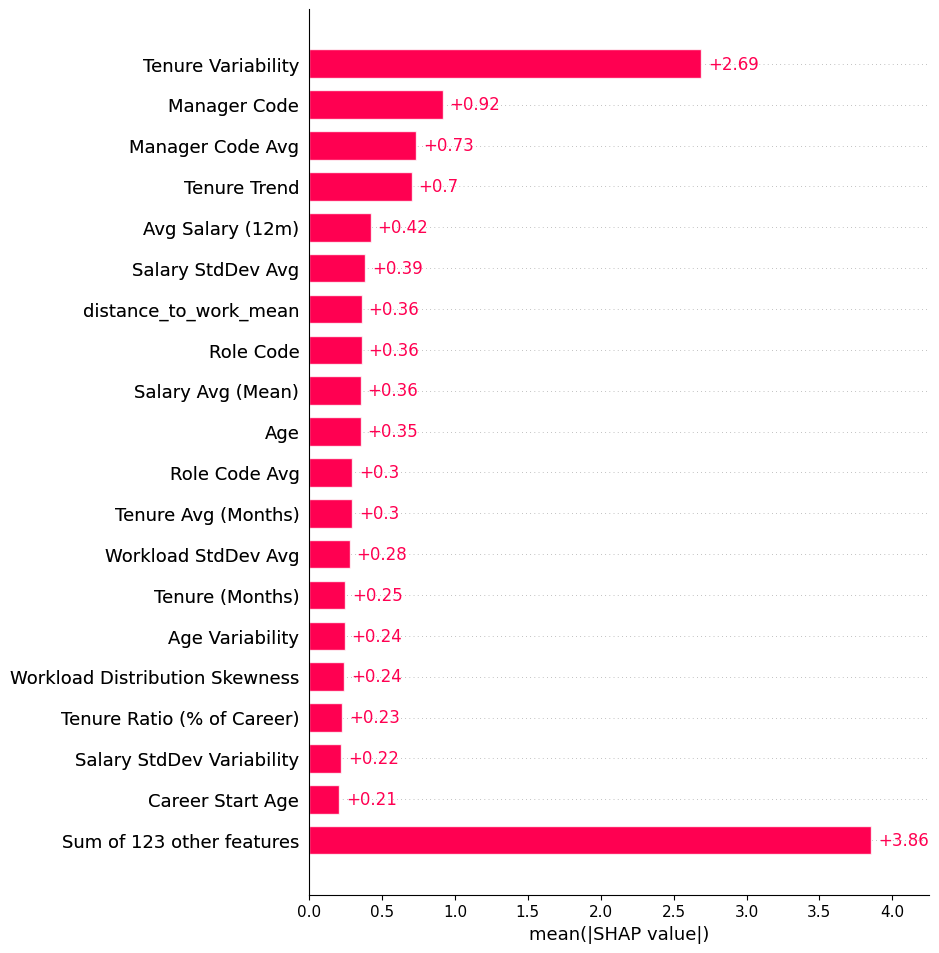

In [12]:
shap.plots.bar(shap_values, max_display=20)

## 5. Beeswarm Plot – Direction & Spread

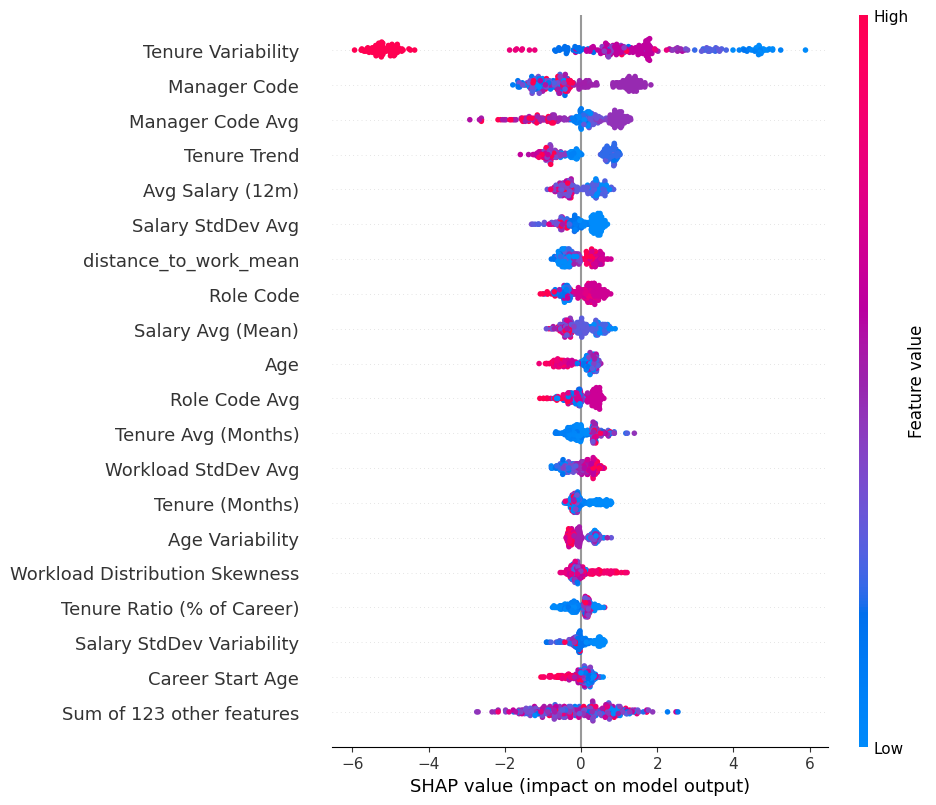

In [13]:
shap.plots.beeswarm(shap_values, max_display=20)

## 6. Scatter (Dependence) Plots for Top Features
X-axis = feature value, Y-axis = SHAP contribution.  
Color = SHAP value of the most-interacting feature (auto-selected by SHAP).

In [14]:
mean_abs_shap       = np.abs(shap_values.values).mean(axis=0)
top_idx             = np.argsort(mean_abs_shap)[::-1][:6]
top_features_raw    = [X_test_num.columns[i] for i in top_idx]
top_features_labels = [FEATURE_DESCRIPTIONS.get(c, c) for c in top_features_raw]
print('Top features:', top_features_labels)

Top features: ['Tenure Variability', 'Manager Code', 'Manager Code Avg', 'Tenure Trend', 'Avg Salary (12m)', 'Salary StdDev Avg']


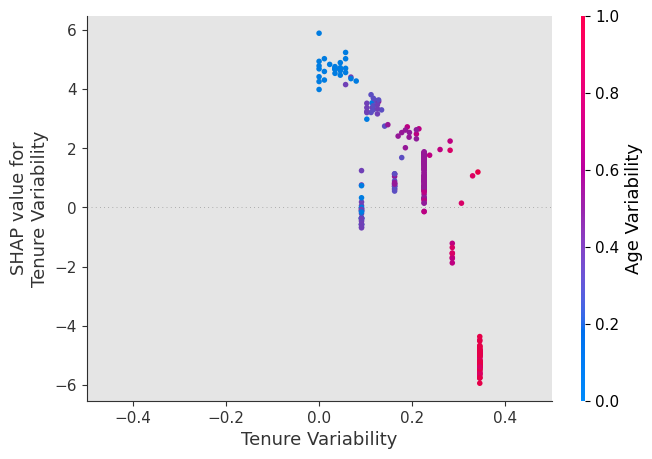

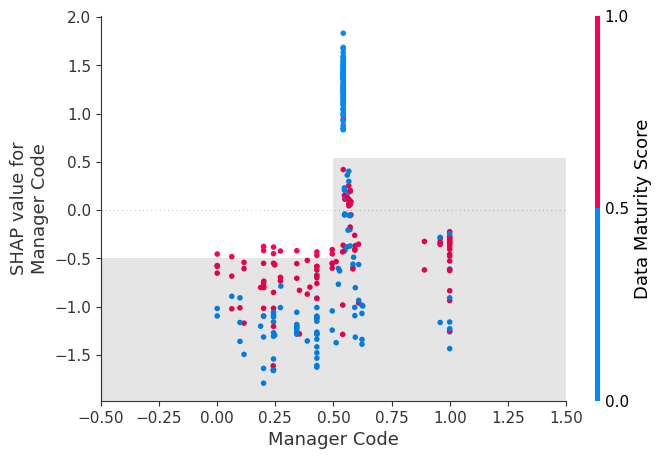

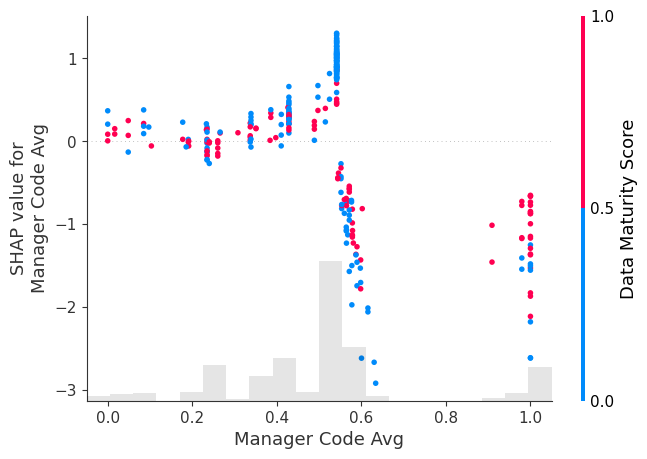

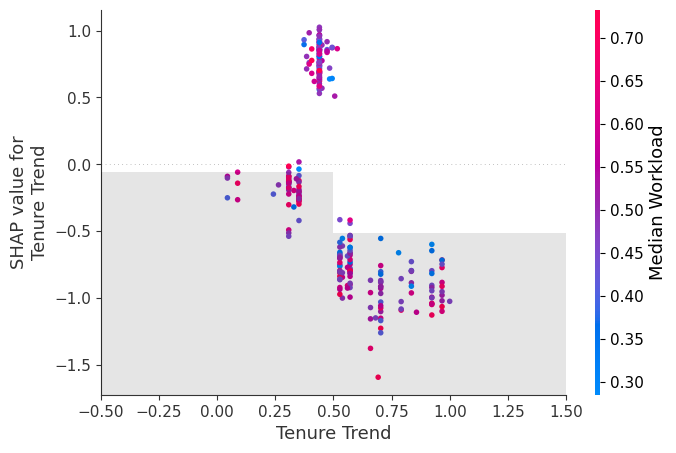

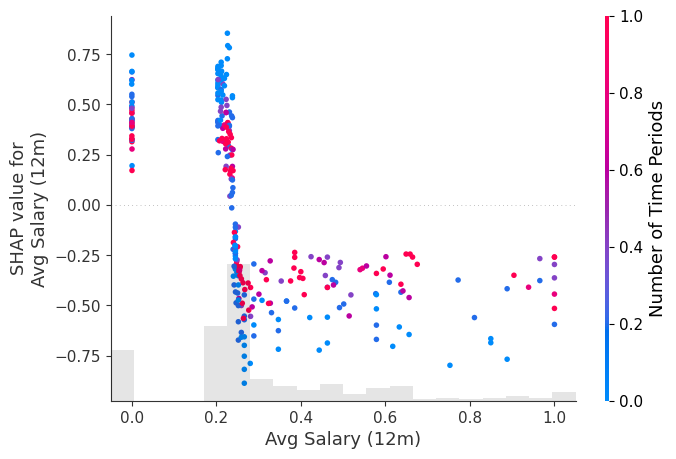

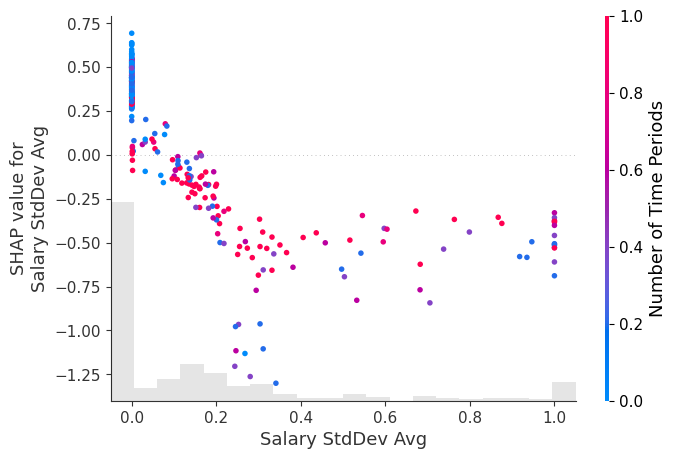

In [15]:
for label in top_features_labels:
    shap.plots.scatter(shap_values[:, label], color=shap_values)

## 7. Waterfall Plot – Highest-Risk Employee

Employee index 128 in test set, predicted churn prob: 100.00%


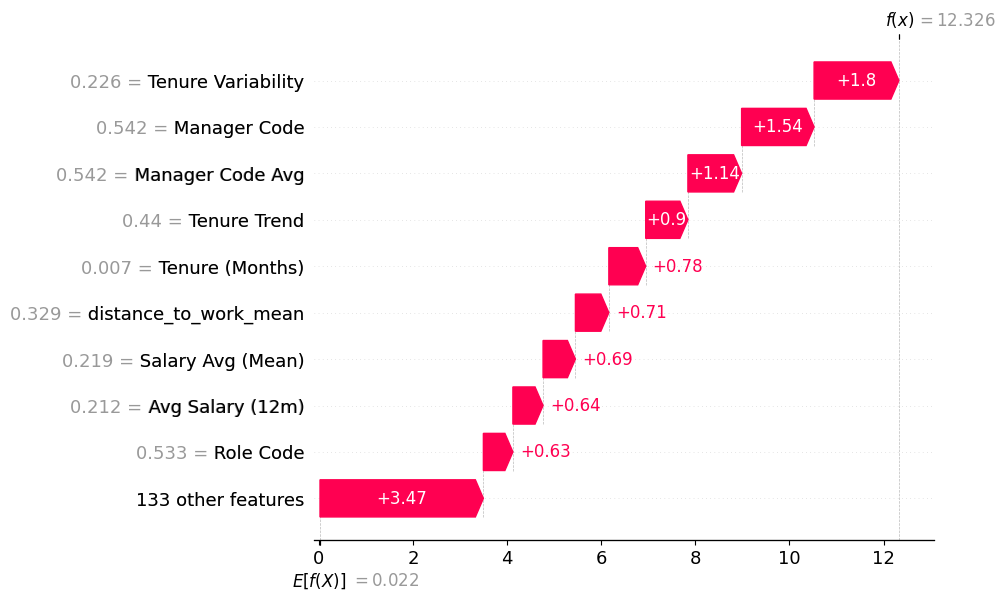

In [16]:
y_prob     = xgb_wrap.predict_proba(X_test_num)
sample_idx = int(np.argmax(y_prob))
print(f'Employee index {sample_idx} in test set, predicted churn prob: {y_prob[sample_idx]:.2%}')

shap.plots.waterfall(shap_values[sample_idx])

## 8. Partial Dependence + SHAP Overlay
PDP for the top feature with the highest-risk employee's SHAP dot overlaid.

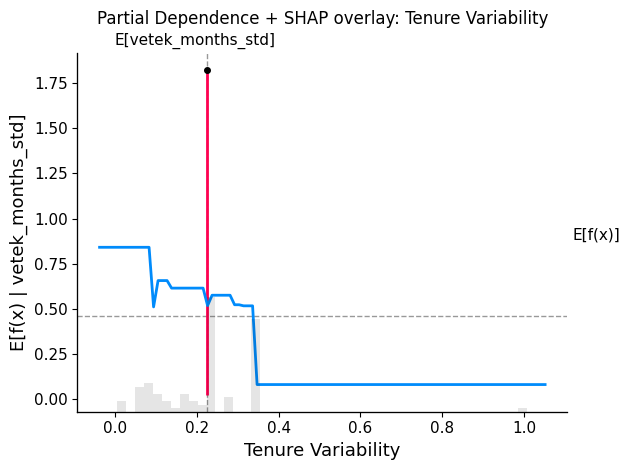

In [17]:
top_feat_raw = top_features_raw[0]
top_feat_label = top_features_labels[0]
background_pdp = background.copy()        
# Use probability for a classifier PDP; keep numeric matrix consistent with explainer.
fig, ax = shap.partial_dependence_plot(
    top_feat_raw, 
    lambda df: xgb_clf.predict_proba(df)[:, 1],
    background_pdp,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
    shap_values=shap_values[sample_idx : sample_idx + 1, :],
)
ax.set_xlabel(top_feat_label)
ax.set_title(f'Partial Dependence + SHAP overlay: {top_feat_label}')
plt.tight_layout()
plt.show()  


## 9. Heatmap – SHAP Values Across Test Set (Top Features)

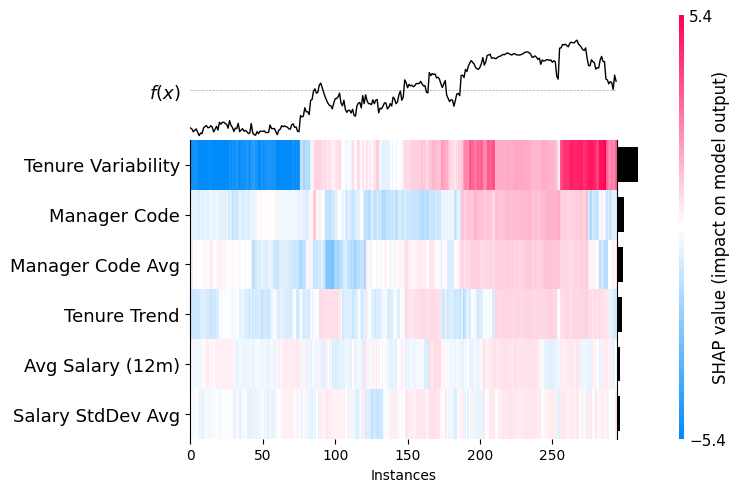

<Axes: xlabel='Instances'>

In [18]:
shap.plots.heatmap(shap_values[:, top_features_labels])

## 10. XGBoost Built-in Feature Importance (gain)
Sanity-check against the SHAP ranking.

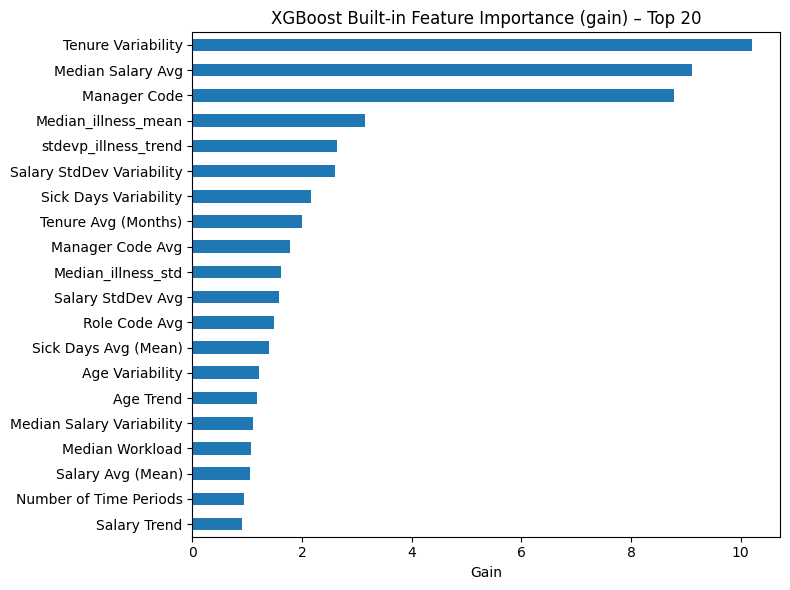

In [19]:
fi = (
    pd.Series(xgb_clf.get_booster().get_score(importance_type='gain'))
    .rename(index=FEATURE_DESCRIPTIONS)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Gain')
ax.set_title('XGBoost Built-in Feature Importance (gain) – Top 20')
plt.tight_layout()
plt.show()